# Random Forest

In [71]:
import xarray as xr
import rioxarray as rxr
import geopandas as gpd
from rasterio.enums import Resampling
from rasterio import features
import numpy as np
import glob
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression

## Prepare data

In [72]:
# import study area
study_area = rxr.open_rasterio('output-data/study-area/study_area_kalimantan.tif').squeeze()

In [73]:
# import predictor layers (squeeze removed band dimension)

drainage_dist = rxr.open_rasterio("output-data/predictor-layers/drainage-dist.tif").squeeze()
forest_dist = rxr.open_rasterio("output-data/predictor-layers/forest-dist.tif").squeeze()
pre_fire_evi_2m = rxr.open_rasterio("output-data/predictor-layers/evi_2month_pre.tif").squeeze()
pre_fire_evi_2y = rxr.open_rasterio("output-data/predictor-layers/evi_2year_pre.tif").squeeze()
post_fire_evi = rxr.open_rasterio('output-data/predictor-layers/post_fire_evi.tif').squeeze()
burn_severity = rxr.open_rasterio("output-data/predictor-layers/reprojected_Burn_Severity.tif").squeeze()
aridity_index = rxr.open_rasterio('output-data/predictor-layers/aridity_index.tif').squeeze()
fire_count = rxr.open_rasterio('output-data/predictor-layers/fire_count.tif').squeeze()
pre_fire_nbr = rxr.open_rasterio('output-data/predictor-layers/reprojected_NBR_PreFire_Kalimantan.tif').squeeze()
post_fire_nbr = rxr.open_rasterio('output-data/predictor-layers/reprojected_NBR_PostFire_Kalimantan.tif').squeeze()
dnbr = pre_fire_nbr - post_fire_nbr

In [75]:
# import vegetation metrics
# I guess i renamed them here as outcome layers, in my folder, i hope is not so confusing
evi_recovery_2y = rxr.open_rasterio("output-data/EVI/dif_evi_short_2017_minus_2015.tif").squeeze()
evi_recovery_5y = rxr.open_rasterio("output-data/EVI/dif_evi_long_2020_minus_2015.tif").squeeze()

perc_evi_recovery_2y = rxr.open_rasterio("output-data/EVI/perc_recovery_2017.tif").squeeze()
perc_evi_recovery_5y = rxr.open_rasterio("output-data/EVI/perc_recovery_2020.tif").squeeze()

In [76]:
# combine in one dataset
ds = xr.Dataset({
    "study_area": study_area,
    # predictors
    "drainage_dist": drainage_dist,
    "forest_dist": forest_dist,
    "pre_fire_evi_2m": pre_fire_evi_2m,
    "pre_fire_evi_2y": pre_fire_evi_2y,
    "burn_severity": burn_severity,
    'aridity_index': aridity_index,
    'fire_count': fire_count,
    'dnbr': dnbr,
    # target variables
    'recovery_2y': evi_recovery_2y,
    'recovery_5y': evi_recovery_5y,
    'perc_recovery_2y': perc_evi_recovery_2y,
    'perc_recovery_5y': perc_evi_recovery_5y
})

In [77]:
# transform to pandas dataframe (only study area pixels)
df = ds.to_dataframe().reset_index()

# remove pixels outside study area
df = df[df.study_area == 1]

### Clean

In [78]:
# drop unnecessary columns
df =  df.drop(['x', 'y', 'band', 'spatial_ref', 'study_area'], axis='columns')

In [83]:
# check data availability (number of np.nan per column)
df.isnull().sum()

drainage_dist           0
forest_dist             0
pre_fire_evi_2m     21158
pre_fire_evi_2y      9357
burn_severity           0
aridity_index           0
fire_count              0
dnbr                21348
recovery_2y         42121
recovery_5y         42019
perc_recovery_2y    34425
perc_recovery_5y    34159
dtype: int64

In [84]:
# remove all rows with at least one nan
df_clean = df.dropna()

In [87]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 5707 entries, 2111942 to 15334694
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   drainage_dist     5707 non-null   float64
 1   forest_dist       5707 non-null   float64
 2   pre_fire_evi_2m   5707 non-null   float32
 3   pre_fire_evi_2y   5707 non-null   float32
 4   burn_severity     5707 non-null   int8   
 5   aridity_index     5707 non-null   float64
 6   fire_count        5707 non-null   uint16 
 7   dnbr              5707 non-null   float32
 8   recovery_2y       5707 non-null   float32
 9   recovery_5y       5707 non-null   float32
 10  perc_recovery_2y  5707 non-null   float64
 11  perc_recovery_5y  5707 non-null   float64
dtypes: float32(5), float64(5), int8(1), uint16(1)
memory usage: 395.7 KB


In [88]:
# make list with predictor column names
predictor_cols = df_clean.columns.to_list()[:-4]
predictor_cols

['drainage_dist',
 'forest_dist',
 'pre_fire_evi_2m',
 'pre_fire_evi_2y',
 'burn_severity',
 'aridity_index',
 'fire_count',
 'dnbr']

In [ ]:
# clean data (remove impossible values 

# remove missing data

## Explore data

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt 

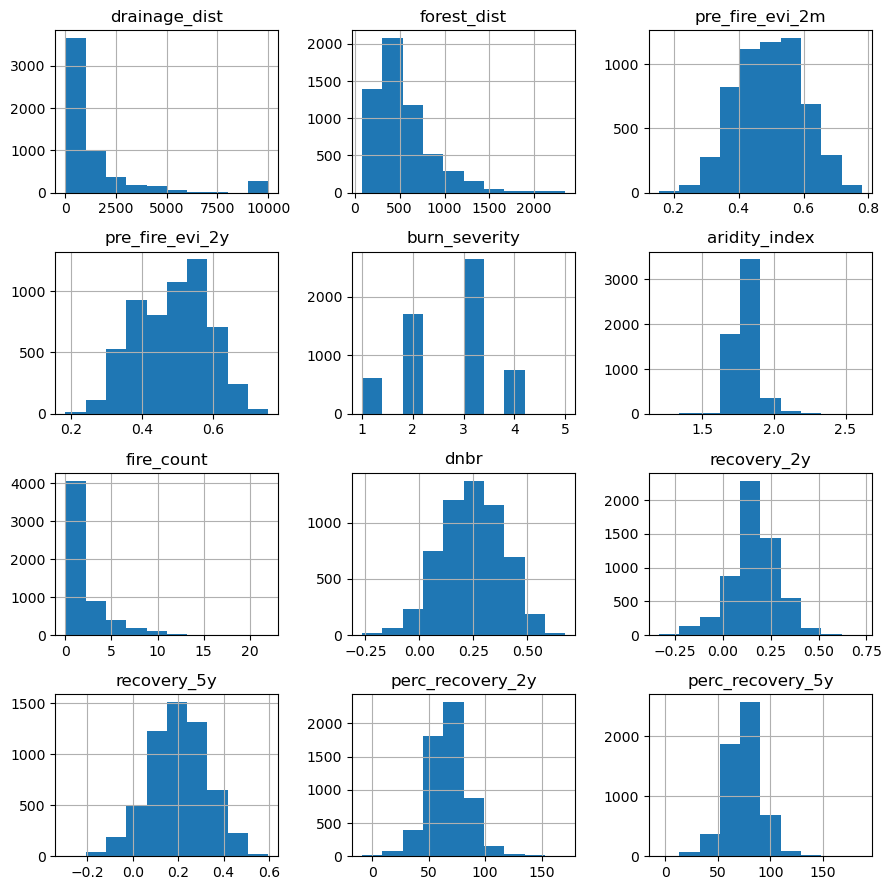

In [104]:
# histograms for all columns
fig, axis = plt.subplots(round(df_clean.shape[1]/3), 3, figsize=(9,9))
df_clean.hist(ax=axis)
plt.tight_layout()
plt.show()

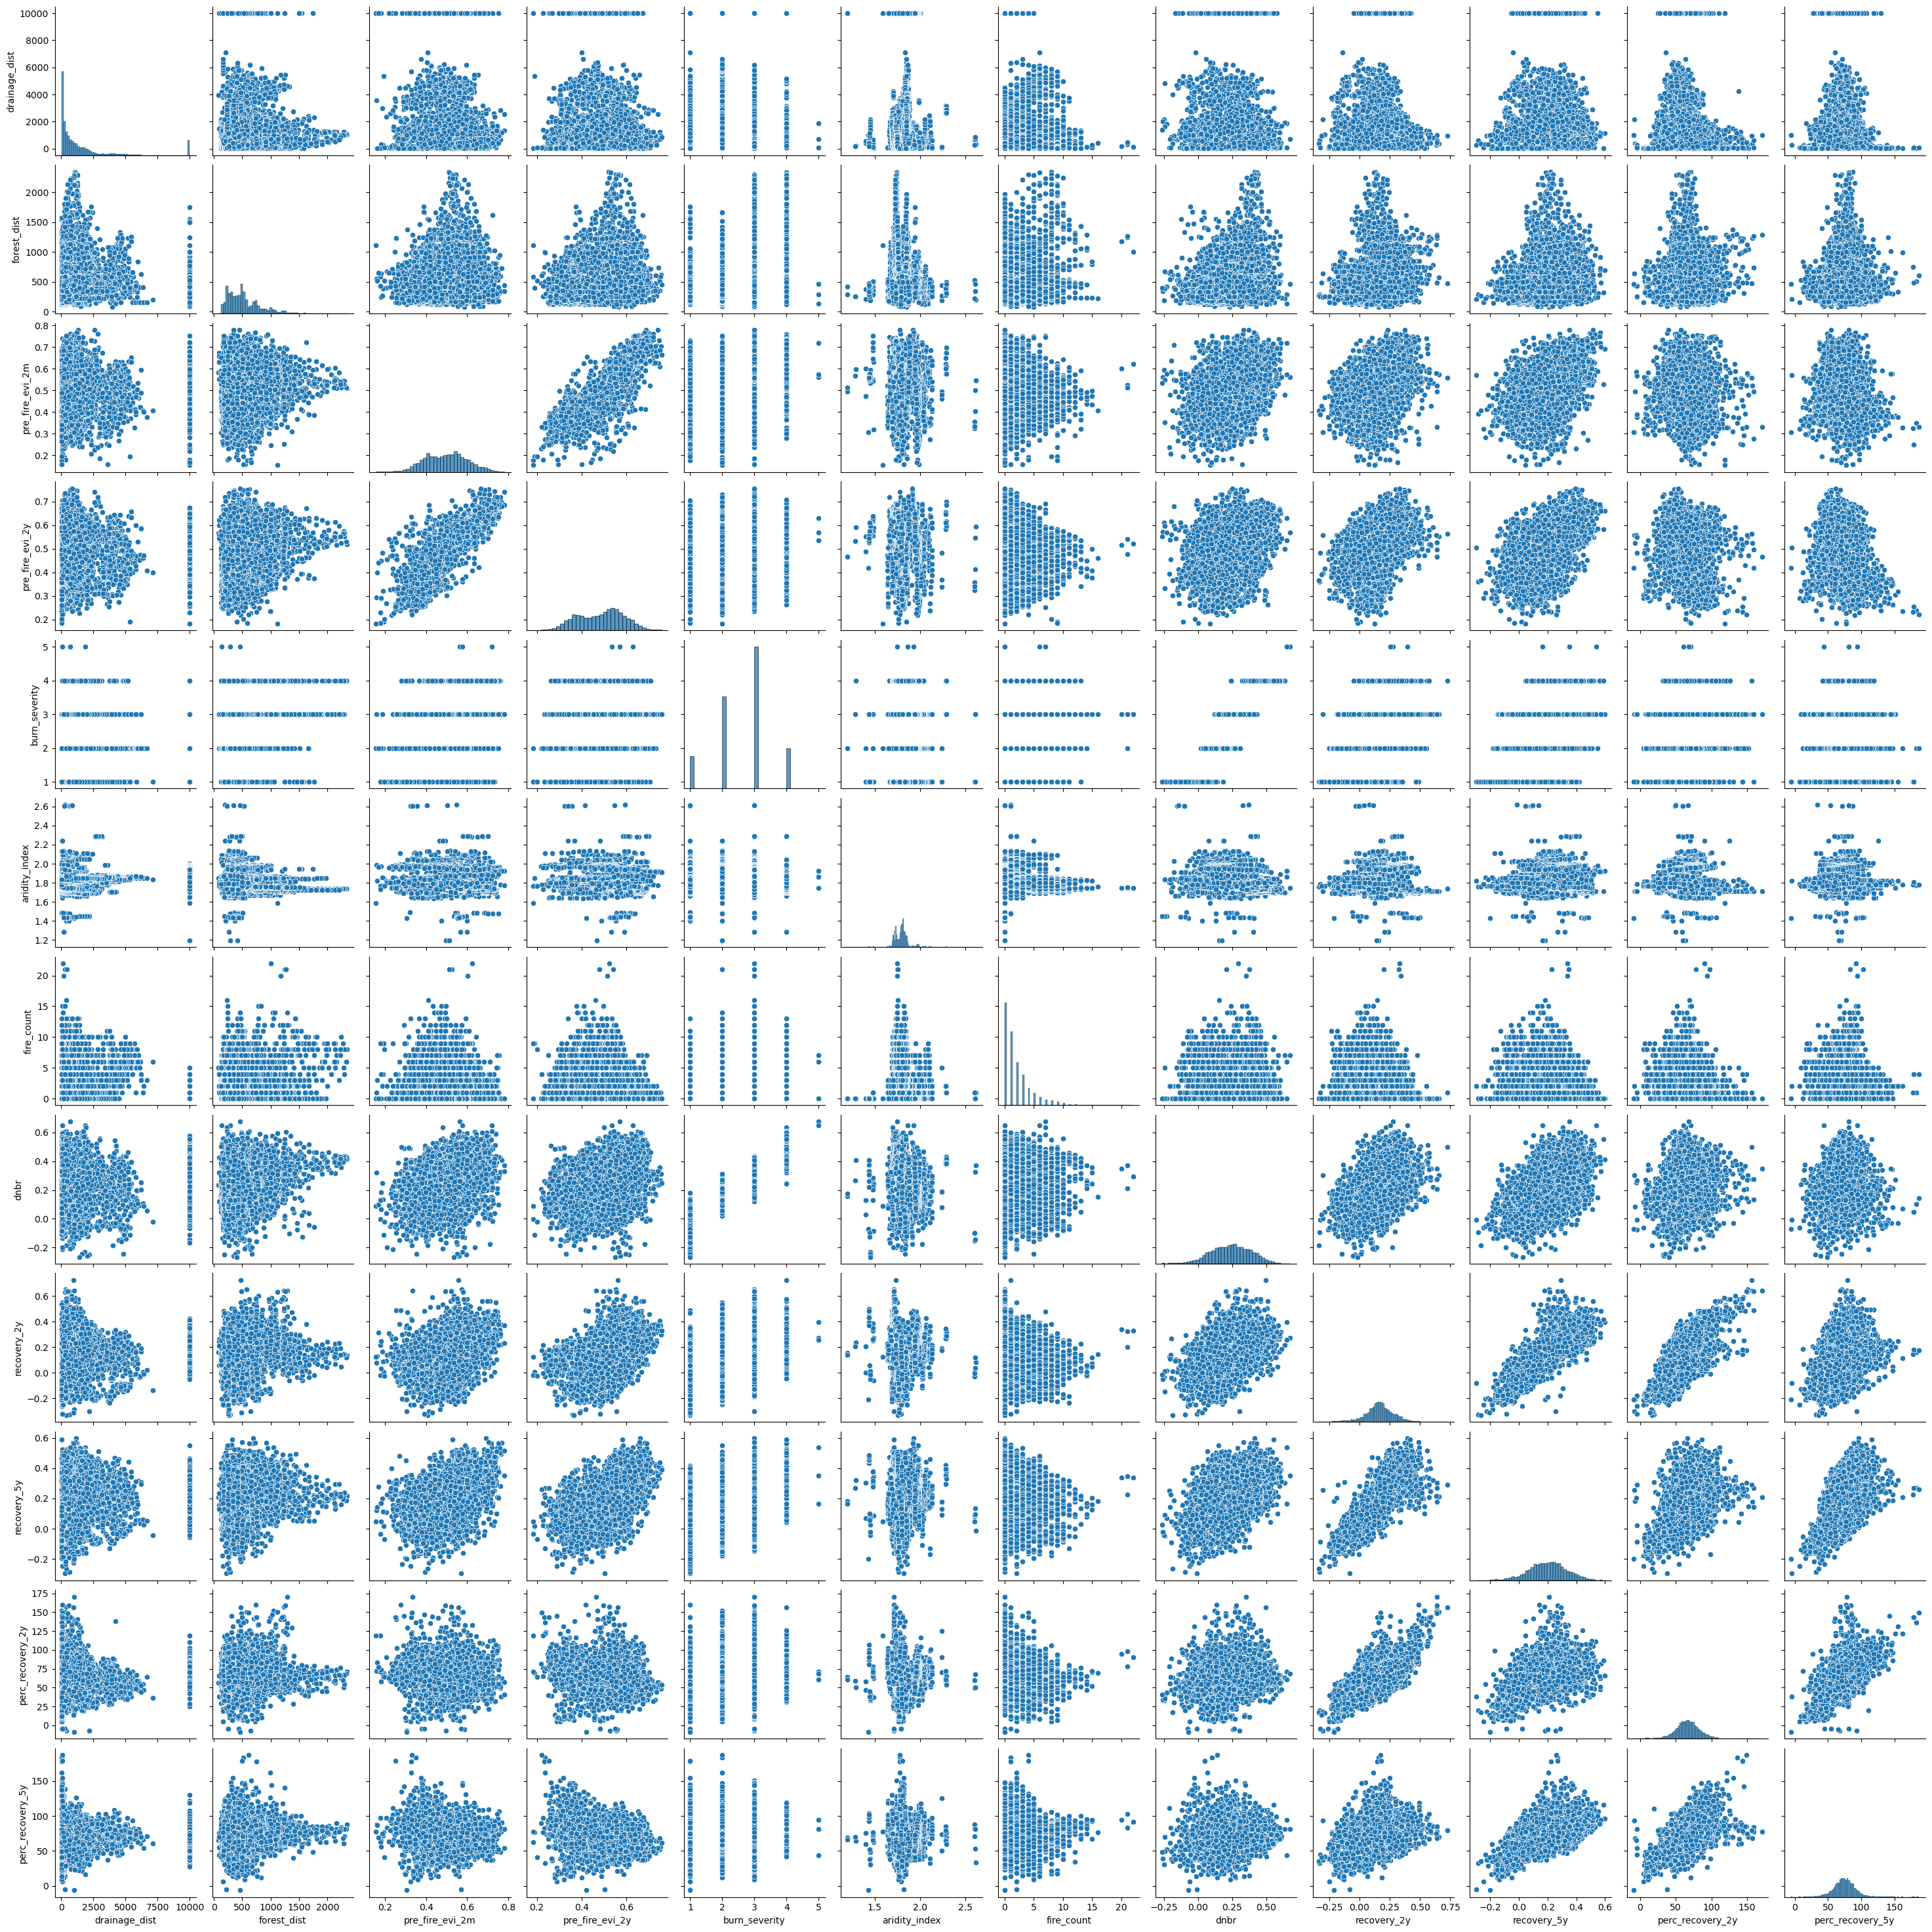

In [92]:
sns.pairplot(df_clean)

## Prepare cross-validation (CV)

In [107]:
# prepare 10-fold CV
from sklearn.model_selection import KFold

# Set up 10-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=123)

# Prepare X and y for both models
X_2y = df_clean[predictor_cols]
y_2y = df_clean["recovery_2y"]
y_2y_perc = df_clean["perc_recovery_2y"]


X_5y = df_clean[predictor_cols]
y_5y = df_clean["recovery_5y"]
y_5y_perc = df_clean["perc_recovery_5y"]


print(f"2-year recovery: {X_2y.shape[0]} samples, {X_2y.shape[1]} features")
print(f"5-year rel. recovery: {X_5y.shape[0]} samples, {X_5y.shape[1]} features")

print(f"2-year recovery: {X_2y.shape[0]} samples, {X_2y.shape[1]} features")
print(f"5-year rel. recovery: {X_5y.shape[0]} samples, {X_5y.shape[1]} features")

2-year recovery: 5707 samples, 8 features
5-year rel. recovery: 5707 samples, 8 features
2-year recovery: 5707 samples, 8 features
5-year rel. recovery: 5707 samples, 8 features


## Fit model

In [111]:
## Fit model
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# set up models
rf_2y = RandomForestRegressor(
    n_estimators=500,
    random_state=123,
    n_jobs=-1  # use all CPU cores
)

rf_5y = RandomForestRegressor(
    n_estimators=500,
    random_state=123,
    n_jobs=-1
)

rf_2y_perc = RandomForestRegressor(
    n_estimators=500,
    random_state=123,
    n_jobs=-1  # use all CPU cores
)

rf_5y_perc = RandomForestRegressor(
    n_estimators=500,
    random_state=123,
    n_jobs=-1
)

# Store CV results
cv_results_2y = {"r2": [], "rmse": [], "mae": []}
cv_results_5y = {"r2": [], "rmse": [], "mae": []}

# 10-fold CV for 2-year model
print("\n=== 2-Year Recovery Model ===")
for fold, (train_idx, test_idx) in enumerate(kf.split(X_2y), 1):
    X_train, X_test = X_2y.iloc[train_idx], X_2y.iloc[test_idx]
    y_train, y_test = y_2y.iloc[train_idx], y_2y.iloc[test_idx]
    
    rf_2y.fit(X_train, y_train)
    y_pred = rf_2y.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    cv_results_2y["r2"].append(r2)
    cv_results_2y["rmse"].append(rmse)
    cv_results_2y["mae"].append(mae)
    
    print(f"Fold {fold}: R² = {r2:.3f}, RMSE = {rmse:.4f}, MAE = {mae:.4f}")

print(f"\nMean R² = {np.mean(cv_results_2y['r2']):.3f} ± {np.std(cv_results_2y['r2']):.3f}")
print(f"Mean RMSE = {np.mean(cv_results_2y['rmse']):.4f} ± {np.std(cv_results_2y['rmse']):.4f}")

# 10-fold CV for 2-year model
print("\n=== 2-Year Relative Recovery Model ===")
for fold, (train_idx, test_idx) in enumerate(kf.split(X_2y), 1):
    X_train, X_test = X_2y.iloc[train_idx], X_2y.iloc[test_idx]
    y_train, y_test = y_2y_perc.iloc[train_idx], y_2y_perc.iloc[test_idx]
    
    rf_2y_perc.fit(X_train, y_train)
    y_pred = rf_2y_perc.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    cv_results_2y["r2"].append(r2)
    cv_results_2y["rmse"].append(rmse)
    cv_results_2y["mae"].append(mae)
    
    print(f"Fold {fold}: R² = {r2:.3f}, RMSE = {rmse:.4f}, MAE = {mae:.4f}")

print(f"\nMean R² = {np.mean(cv_results_2y['r2']):.3f} ± {np.std(cv_results_2y['r2']):.3f}")
print(f"Mean RMSE = {np.mean(cv_results_2y['rmse']):.4f} ± {np.std(cv_results_2y['rmse']):.4f}")

# 10-fold CV for 5-year model
print("\n=== 5-Year Recovery Model ===")
for fold, (train_idx, test_idx) in enumerate(kf.split(X_5y), 1):
    X_train, X_test = X_5y.iloc[train_idx], X_5y.iloc[test_idx]
    y_train, y_test = y_5y.iloc[train_idx], y_5y.iloc[test_idx]
    
    rf_5y.fit(X_train, y_train)
    y_pred = rf_5y.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    cv_results_5y["r2"].append(r2)
    cv_results_5y["rmse"].append(rmse)
    cv_results_5y["mae"].append(mae)
    
    print(f"Fold {fold}: R² = {r2:.3f}, RMSE = {rmse:.4f}, MAE = {mae:.4f}")

print(f"\nMean R² = {np.mean(cv_results_5y['r2']):.3f} ± {np.std(cv_results_5y['r2']):.3f}")
print(f"Mean RMSE = {np.mean(cv_results_5y['rmse']):.4f} ± {np.std(cv_results_5y['rmse']):.4f}")

# 10-fold CV for relative 5-year model
print("\n=== 5-Year Relative Recovery Model ===")
for fold, (train_idx, test_idx) in enumerate(kf.split(X_5y), 1):
    X_train, X_test = X_5y.iloc[train_idx], X_5y.iloc[test_idx]
    y_train, y_test = y_5y_perc.iloc[train_idx], y_5y_perc.iloc[test_idx]
    
    rf_5y_perc.fit(X_train, y_train)
    y_pred = rf_5y_perc.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    cv_results_5y["r2"].append(r2)
    cv_results_5y["rmse"].append(rmse)
    cv_results_5y["mae"].append(mae)
    
    print(f"Fold {fold}: R² = {r2:.3f}, RMSE = {rmse:.4f}, MAE = {mae:.4f}")

print(f"\nMean R² = {np.mean(cv_results_5y['r2']):.3f} ± {np.std(cv_results_5y['r2']):.3f}")
print(f"Mean RMSE = {np.mean(cv_results_5y['rmse']):.4f} ± {np.std(cv_results_5y['rmse']):.4f}")

# Fit final models on full data
rf_2y.fit(X_2y, y_2y)
rf_5y.fit(X_5y, y_5y)


=== 2-Year Recovery Model ===
Fold 1: R² = 0.601, RMSE = 0.0791, MAE = 0.0567
Fold 2: R² = 0.613, RMSE = 0.0749, MAE = 0.0531
Fold 3: R² = 0.671, RMSE = 0.0709, MAE = 0.0517
Fold 4: R² = 0.613, RMSE = 0.0806, MAE = 0.0550
Fold 5: R² = 0.649, RMSE = 0.0697, MAE = 0.0518
Fold 6: R² = 0.643, RMSE = 0.0711, MAE = 0.0517
Fold 7: R² = 0.601, RMSE = 0.0791, MAE = 0.0550
Fold 8: R² = 0.661, RMSE = 0.0725, MAE = 0.0532
Fold 9: R² = 0.650, RMSE = 0.0769, MAE = 0.0543
Fold 10: R² = 0.600, RMSE = 0.0784, MAE = 0.0550

Mean R² = 0.630 ± 0.026
Mean RMSE = 0.0753 ± 0.0038

=== 2-Year Relative Recovery Model ===
Fold 1: R² = 0.520, RMSE = 12.9929, MAE = 8.7384
Fold 2: R² = 0.555, RMSE = 11.8560, MAE = 8.0368
Fold 3: R² = 0.605, RMSE = 10.5571, MAE = 7.6381
Fold 4: R² = 0.505, RMSE = 13.2601, MAE = 8.5622
Fold 5: R² = 0.568, RMSE = 11.5790, MAE = 8.1070
Fold 6: R² = 0.665, RMSE = 10.5072, MAE = 7.6824
Fold 7: R² = 0.587, RMSE = 12.1568, MAE = 8.2532
Fold 8: R² = 0.550, RMSE = 12.0063, MAE = 8.2276
Fol

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## Model accuracy

## Variable importance

In [112]:
import pandas as pd

# 2-year model importance
importance_2y = pd.DataFrame({
    "variable": X_2y.columns,
    "importance": rf_2y.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_2y)

          variable  importance
3  pre_fire_evi_2y    0.253158
7             dnbr    0.215499
5    aridity_index    0.194077
0    drainage_dist    0.117992
1      forest_dist    0.073177
2  pre_fire_evi_2m    0.073053
6       fire_count    0.066068
4    burn_severity    0.006976


In [114]:
importance_5y = pd.DataFrame({
    "variable": X_5y.columns,
    "importance": rf_5y.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_5y)

          variable  importance
3  pre_fire_evi_2y    0.364170
7             dnbr    0.210645
5    aridity_index    0.141128
0    drainage_dist    0.102332
1      forest_dist    0.071883
2  pre_fire_evi_2m    0.064622
6       fire_count    0.039372
4    burn_severity    0.005848


In [113]:
importance_2y = pd.DataFrame({
    "variable": X_5y.columns,
    "importance": rf_2y_perc.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_2y)

          variable  importance
5    aridity_index    0.229915
3  pre_fire_evi_2y    0.226613
7             dnbr    0.128226
0    drainage_dist    0.127432
2  pre_fire_evi_2m    0.093776
6       fire_count    0.092409
1      forest_dist    0.089548
4    burn_severity    0.012080


In [115]:
importance_5y = pd.DataFrame({
    "variable": X_5y.columns,
    "importance": rf_5y_perc.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_2y)

          variable  importance
5    aridity_index    0.229915
3  pre_fire_evi_2y    0.226613
7             dnbr    0.128226
0    drainage_dist    0.127432
2  pre_fire_evi_2m    0.093776
6       fire_count    0.092409
1      forest_dist    0.089548
4    burn_severity    0.012080


## Partial dependence plots